<a href="https://colab.research.google.com/github/diegogr98/Diego-Gutierrez-Astronomy/blob/main/Planet_interior_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Autor:** Diego Gutierrez

**objetivo:**
*Hacer un modelo numérico del interior de planeta sólido y usarlo para
estudiar la propagación de ondas sísmicas.*

##1. Datos del modelo PREM
• Obtener datos de densidad, velocidad de ondas P y S del modelo PREM.

• Calcular $K$ (módulo de compresibilidad) y $μ$ (módulo de rigidez) a cada profundidad.

• Graficar $K(r)$ y $μ(r)$. Determinar los radios del manto inferior, núcleo externo
e interno.

In [ ]:
!pip install -Uq rockhound

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import rockhound as rh
from scipy.optimize import curve_fit, root_scalar, newton
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

* Código fuente del PREM: https://github.com/fatiando/rockhound
* Para ver cuales son las unidades que da el PREM: https://www.sciencedirect.com/science/article/abs/pii/0031920181900467?via%3Dihub

In [ ]:
#@title Cargar el modelo PREM
prem = rh.fetch_prem()

In [ ]:
#Radio y densidad (invertidos)
r = np.array(prem.radius[::-1]) * 1000 #m
rho = np.array(prem.density[::-1]) * 1000 #kg/m^3

#Velocidad ondas
vp = np.array(prem.Vpv[::-1]) * 1000 #m/s
vs = np.array(prem.Vsv[::-1]) * 1000 #m/s

In [ ]:
#@title Calculando los modulos de compresibilidad y rigidez
K = rho * (vp**2 - (4/3)*vs**2) #Pa
mu = rho * vs**2 #Pa

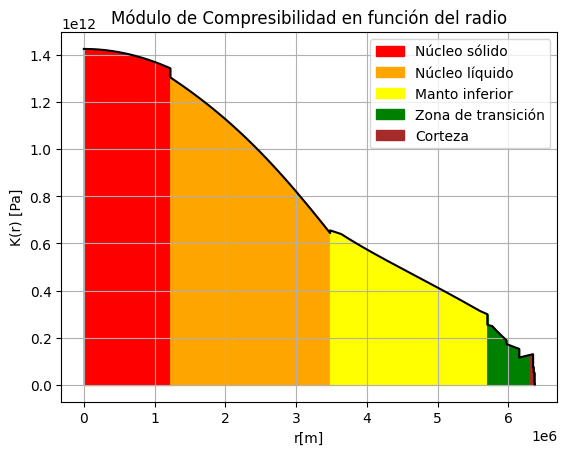

In [ ]:
# Modulo de compresibilidad
capas = [(0, 1221e3), (1221e3, 3480e3), (3480e3, 5701e3),
          (5701e3, 6300e3), (6300e3, 6371e3)]
colores = ["red", "orange", "yellow", "green","brown"]
etiquetas = [ "Núcleo sólido", "Núcleo líquido", "Manto inferior",
             "Zona de transición", "Corteza"]

plt.figure()

for i, (b, e) in enumerate(capas):
    filtro = (r >= b) & (r <= e)
    plt.fill_between(r[filtro], K[filtro], color=colores[i], label=etiquetas[i])

plt.title("Módulo de Compresibilidad en función del radio")
plt.xlabel("r[m]")
plt.ylabel("K(r) [Pa]")
plt.plot(r,K, color = "black")
plt.legend()
plt.grid();

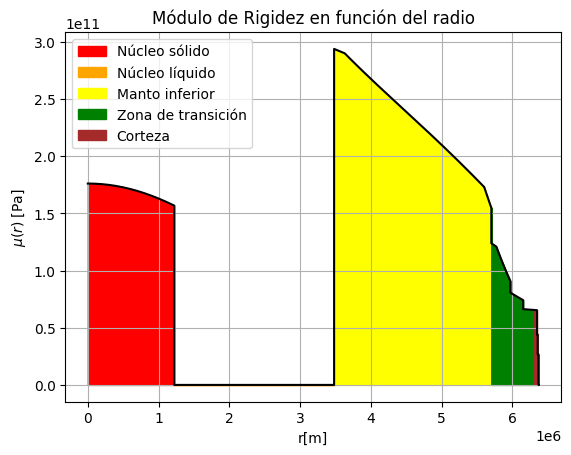

In [ ]:
# Modulo de rigidez
plt.figure()

for i, (b, e) in enumerate(capas):
    filtro = (r >= b) & (r <= e)
    plt.fill_between(r[filtro], mu[filtro], color=colores[i], label=etiquetas[i])

plt.title("Módulo de Rigidez en función del radio")
plt.xlabel("r[m]")
plt.ylabel(r"$\mu(r)$ [Pa]")
plt.plot(r,mu,color = "black")
plt.legend()
plt.grid();

## 2. Ajuste funcional de los módulos

Se supone que:

$$K(ρ) = aρ^\text{nk} ,\quad  μ(ρ) = bρ^\text{nμ}$$

*  Ajustar parámetros $a$, $n_K$, $b$, $n_μ$ para el manto sólido y núcleo liquido.
*  Escribir funciones generalizadas para calcular K y μ en función de ρ.

In [ ]:
# Definir función de ajuste en escala logarítmica
def log_power_law(log_rho, log_a, n):
    return log_a + n * log_rho

# Núcleo líquido (r < 1221 km)
filtro_nucleo = (r < 1221e3)
rho_nucleo = rho[filtro_nucleo]
K_nucleo = K[filtro_nucleo]
mu_nucleo = mu[filtro_nucleo]  # En el núcleo líquido, μ ≈ 0

# Manto sólido (3480 km < r < 5701 km)
filtro_manto = (r > 3480e3) & (r < 5701e3)
rho_manto = rho[filtro_manto]
K_manto = K[filtro_manto]
mu_manto = mu[filtro_manto]


# Ajuste lineal para K en el manto
log_rho_manto = np.log(rho_manto)
log_K_manto = np.log(K_manto)
popt_K_manto, _ = curve_fit(log_power_law,
                            log_rho_manto,
                            log_K_manto, p0=[25, 1])  # log_a ≈ ln(1e11) ~ 25

# Convertir parámetros de vuelta a escala normal
a_K_manto = np.exp(popt_K_manto[0])
nK_manto = popt_K_manto[1]

# 3. Ajuste para μ en el manto
log_mu_manto = np.log(mu_manto)
popt_mu_manto, _ = curve_fit(log_power_law,
                             log_rho_manto,
                             log_mu_manto, p0=[25, 1])
b_mu_manto = np.exp(popt_mu_manto[0])
nmu_manto = popt_mu_manto[1]

# 4. Ajuste para K en el núcleo líquido
log_rho_nucleo = np.log(rho_nucleo)
log_K_nucleo = np.log(K_nucleo)
popt_K_nucleo, _ = curve_fit(log_power_law,
                             log_rho_nucleo,
                             log_K_nucleo, p0=[25, 1])
a_K_nucleo = np.exp(popt_K_nucleo[0])
nK_nucleo = popt_K_nucleo[1]

# Resultados
print("Ajuste Manto Sólido:")
print(f"K(ρ) = {a_K_manto:.2e} * ρ^{nK_manto:.2f}")
print(f"μ(ρ) = {b_mu_manto:.2e} * ρ^{nmu_manto:.2f}\n")

print("Ajuste Núcleo Líquido:")
print(f"K(ρ) = {a_K_nucleo:.2e} * ρ^{nK_nucleo:.2f}")
print("μ(ρ) ≈ 0 (fluido)")

Ajuste Manto Sólido:
K(ρ) = 2.40e-01 * ρ^3.32
μ(ρ) = 2.00e+02 * ρ^2.45

Ajuste Núcleo Líquido:
K(ρ) = 2.83e+02 * ρ^2.36
μ(ρ) ≈ 0 (fluido)


In [ ]:
# Funciones generaliadas
def K_model(rho, capa):
    if capa == "manto":
        return a_K_manto * rho**nK_manto
    elif capa == "nucleo":
        return a_K_nucleo * rho**nK_nucleo
    else:
        raise ValueError("Capa no válida")

def mu_model(rho, capa):
    if capa == "manto":
        return b_mu_manto * rho**nmu_manto
    elif capa == "nucleo":
        return np.zeros_like(rho)  # o simplemente 0 si rho es escalar
    else:
        raise ValueError("Capa no válida")

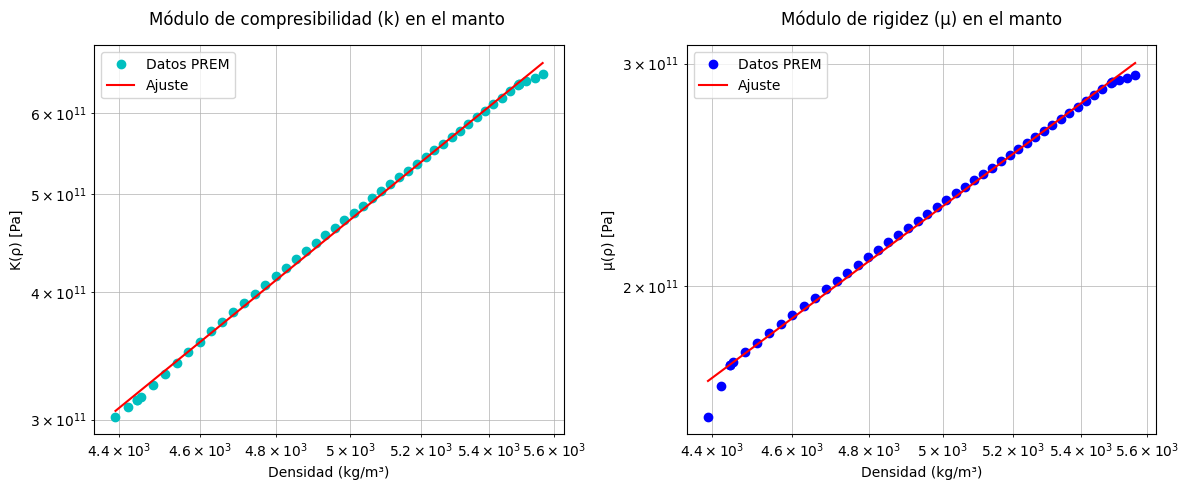

In [ ]:
plt.figure(figsize=(12, 5))
# Gráfico para K en el manto (log-log)
plt.subplot(121)
plt.loglog(rho_manto, K_manto, 'co', label='Datos PREM')
plt.loglog(rho_manto, K_model(rho_manto, "manto"), 'r-', label='Ajuste')
plt.xlabel('Densidad (kg/m³)')
plt.ylabel('K(ρ) [Pa]')
plt.grid(True, which='both',linestyle='-', linewidth=0.5)
plt.title('Módulo de compresibilidad (k) en el manto ', pad=15)
plt.legend()

# Gráfico para μ en el manto (log-log)
plt.subplot(122)
plt.loglog(rho_manto, mu_manto, 'bo', label='Datos PREM')
plt.loglog(rho_manto, mu_model(rho_manto, "manto"), 'r-', label='Ajuste')
plt.xlabel('Densidad (kg/m³)')
plt.ylabel('μ(ρ) [Pa]')
plt.grid(True, which='both',linestyle='-', linewidth=0.5)
plt.title('Módulo de rigidez (μ) en el manto', pad=15)
plt.legend()

plt.tight_layout()
plt.show()

##3. Construcción del planeta modelo
Se resuelven las siguientes ecuaciones:

$$
\frac{dp}{dr} = - \rho g, \quad \text{donde } g = \frac{G M_r}{r^2}
$$


$$
\frac{dM_r}{dr} = 4 \pi r^2 \rho
$$


$$
\frac{d \rho}{dr} = - \frac{\rho^2 g}{K(\rho)}
$$

<br>

* Condiciones iniciales: $p(R) = 0$, $Mr(R) = Mm$, $ρ(R) = 3000$.
* Se asume que el n ́ucleo comienza en $r_N = 0.5R$, con un salto de densidad del 70%.
* Integrar hasta el centro (sin llegar a r = 0), observar y graficar ρ(r), p(r), Mr(r).

In [ ]:
# Constantes del problema
G = 6.67430e-11
R = 6.4e6
r_nucleo = 0.5 * R

# condiciones iniciales en el centro
rho_nucleo = 12000        # kg/m³
p_c = 3.6e11              # Pa
M_0 = 0

y0 = [p_c, M_0, rho_nucleo]

In [ ]:
# Resolviendo el sistema de ecuaciones diferenciales
def sistema(r, y):
    p, M_r, rho = y
    rho = max(rho, 1.0)

    if r == 0:
        g = 0
    else:
        g = G * M_r / r**2

    # módulo de compresibilidad
    if r <= r_nucleo:
        K = 283 * rho**2.36
    else:
        K = 0.24 * rho**3.32

    dpdr = -rho * g
    dMdr = 4 * np.pi * r**2 * rho
    drhodr = -rho**2 * g / K

    return [dpdr, dMdr, drhodr]

#integración desde el centro hasta el límite núcleo-manto
r_eval1 = np.linspace(1, r_nucleo, 2500)
sol1 = solve_ivp(sistema, [1, r_nucleo], y0, method="RK45", t_eval=r_eval1)

# aplicar descenso de densidad del 70% (pasar de núcleo a manto)
p_jump = sol1.y[0][-1]
M_jump = sol1.y[1][-1]
rho_jump = sol1.y[2][-1] / 1.7  # disminuye densidad al salir del núcleo

y_jump = [p_jump, M_jump, rho_jump]

#integración del manto hasta la superficie
r_eval2 = np.linspace(r_nucleo, R, 2500)
sol2 = solve_ivp(sistema,
                 [r_nucleo, R],
                 y_jump, method="RK45",
                 t_eval=r_eval2)

# --- unir resultados ---
r = np.concatenate((sol1.t, sol2.t))
p = np.concatenate((sol1.y[0], sol2.y[0]))
M_r = np.concatenate((sol1.y[1], sol2.y[1]))
rho = np.concatenate((sol1.y[2], sol2.y[2]))

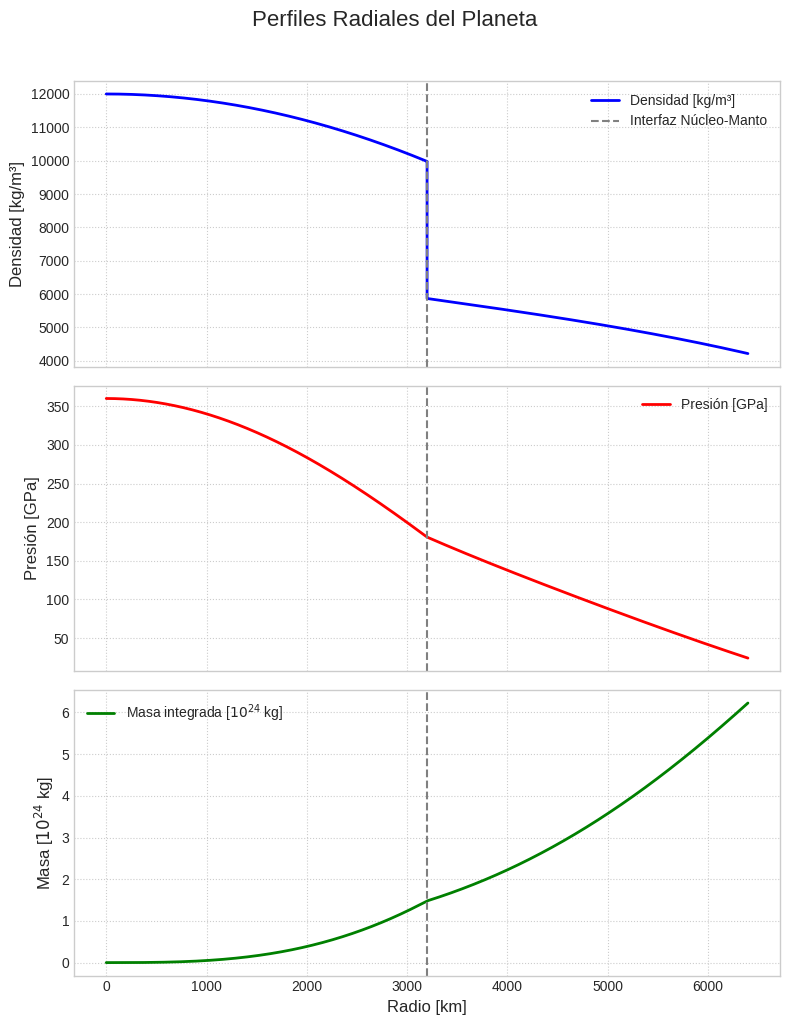

In [ ]:
# Crear figura con 3 subplots
plt.style.use('seaborn-v0_8-whitegrid')  # Estilo moderno
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# Gráfico 1: Densidad
ax1.plot(r/1e3, rho, color='blue', linewidth=2,
         label='Densidad [kg/m³]')
ax1.axvline(r_nucleo/1e3, color='gray', linestyle='--',
            linewidth=1.5, label='Interfaz Núcleo-Manto')
ax1.set_ylabel('Densidad [kg/m³]', fontsize=12)
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, linestyle=':', linewidth=0.8)

# Gráfico 2: Presión
ax2.plot(r/1e3, p/1e9, color='red', linewidth=2, label='Presión [GPa]')
ax2.axvline(r_nucleo/1e3, color='gray', linestyle='--', linewidth=1.5)
ax2.set_ylabel('Presión [GPa]', fontsize=12)
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, linestyle=':', linewidth=0.8)

# Gráfico 3: Masa
ax3.plot(r/1e3, M_r/1e24, color='green',
         linewidth=2, label='Masa integrada [$10^{24}$ kg]')
ax3.axvline(r_nucleo/1e3, color='gray', linestyle='--', linewidth=1.5)
ax3.set_xlabel('Radio [km]', fontsize=12)
ax3.set_ylabel('Masa [$10^{24}$ kg]', fontsize=12)
ax3.legend(fontsize=10, loc='best')
ax3.grid(True, linestyle=':', linewidth=0.8)

# Título general
fig.suptitle('Perfiles Radiales del Planeta', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

##4. Cálculo del radio correcto (overshooting)
* Si $M_r/M_t$ en el centro es positivo, aumentar R.
* Si es negativo, disminuir R.
* Encontrar el valor  ́optimo de R tal que Mr/Mm ≈ 0 en el centro.
* Graficar: $Mr(r), g(r), p(r), ρ(r), K(r), μ(r), v_s(r), v_P (r)$.

In [ ]:
#Constantes
M_objetivo = 5.972e24  #kg


#Función de error en masa final
def error_masa(R):
    #integración desde el centro hasta el límite núcleo-manto
    r_eval1 = np.linspace(1, r_nucleo, 2500)
    sol1 = solve_ivp(sistema, [1, r_nucleo], y0, method="RK45", t_eval=r_eval1)

    # aplicar descenso de densidad del 70% (pasar de núcleo a manto)
    p_jump = sol1.y[0][-1]
    M_jump = sol1.y[1][-1]
    rho_jump = sol1.y[2][-1] / 1.7

    y_jump = [p_jump, M_jump, rho_jump]

    #integración del manto hasta la superficie
    r_eval2 = np.linspace(r_nucleo, R, 2500)
    sol2 = solve_ivp(sistema,
                     [r_nucleo, R],
                     y_jump, method="RK45",
                     t_eval=r_eval2)

    M_final = sol2.y[1][-1]

    return M_final - M_objetivo

#Estimación inicial
R_inicial = 6.4e6  #m

#Método de Newton
R_optimo = newton(error_masa, x0=R_inicial, maxiter=50, tol=1e20)

print("="*60)
print(f"Radio óptimo encontrado: {R_optimo} m")
print("="*60)

Radio óptimo encontrado: 6283103.319928251 m


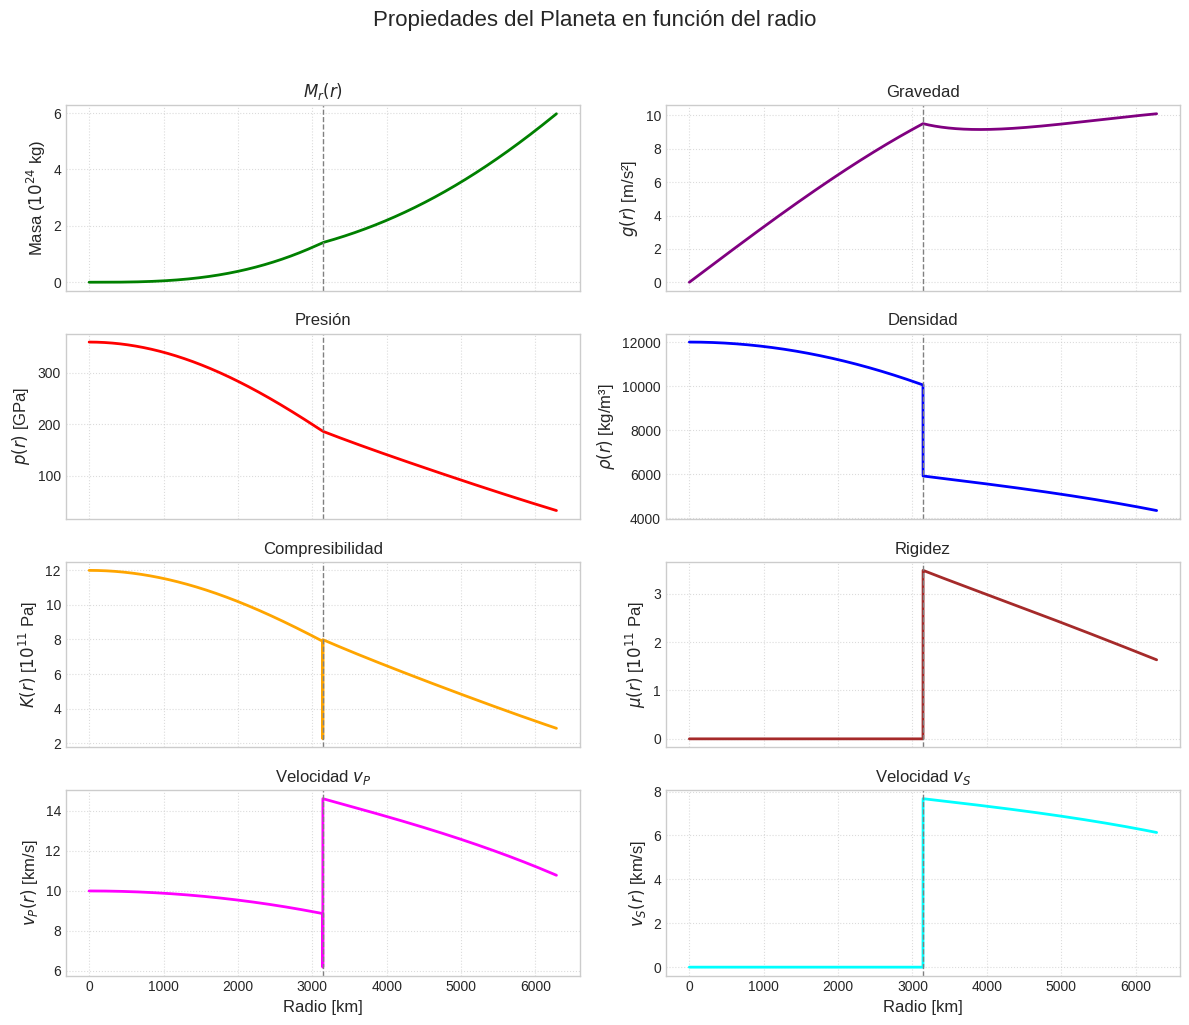

In [ ]:
r_nucleo = 0.5 * R_optimo  # Radio del núcleo

# Integración desde el centro hasta la superficie
r_eval1 = np.linspace(1, r_nucleo, 2500)
sol1 = solve_ivp(sistema, [1, r_nucleo], y0, method="RK45", t_eval=r_eval1)
p_jump, M_jump, rho_jump = sol1.y[0][-1], sol1.y[1][-1], sol1.y[2][-1] / 1.7
r_eval2 = np.linspace(r_nucleo, R_optimo, 2500)
sol2 = solve_ivp(sistema, [r_nucleo, R_optimo],
                 [p_jump, M_jump, rho_jump],
                 method="RK45",
                 t_eval=r_eval2)

# Unir resultados
r = np.concatenate((sol1.t, sol2.t))
p = np.concatenate((sol1.y[0], sol2.y[0]))
M_r = np.concatenate((sol1.y[1], sol2.y[1]))
rho = np.concatenate((sol1.y[2], sol2.y[2]))

# Calcular variables derivadas
g = G * M_r / r**2
g[0] = 0  # Evitar división por cero en r=0
K = np.where(r <= r_nucleo, 283 * rho**2.36, 0.24 * rho**3.32)
mu = np.where(r <= r_nucleo, 0, b_mu_manto * rho**nmu_manto)
v_p = np.sqrt((K + 4/3 * mu) / rho)
v_s = np.sqrt(mu / rho)

# Crear figura con subplots
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(4, 2, figsize=(12, 10), sharex=True)
fig.suptitle('Propiedades del Planeta en función del radio',
             fontsize=16, y=1.02)

# Configuración común
def plot_property(ax, x, y, color, ylabel, title, logy=False):
    ax.plot(x/1e3, y, color=color, linewidth=2)
    ax.axvline(r_nucleo/1e3, color='gray', linestyle='--', linewidth=1)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.7)


# Gráficos
plot_property(axs[0, 0], r, M_r/1e24, 'green',
              'Masa ($10^{24}$ kg)', '$M_r(r)$')
plot_property(axs[0, 1], r, g, 'purple', '$g(r)$ [m/s²]', 'Gravedad')

plot_property(axs[1, 0], r, p/1e9, 'red', '$p(r)$ [GPa]', 'Presión')
plot_property(axs[1, 1], r, rho, 'blue', '$\\rho(r)$ [kg/m³]', 'Densidad')

plot_property(axs[2, 0], r, K/1e11, 'orange', '$K(r)$ [$10^{11}$ Pa]',
              'Compresibilidad')
plot_property(axs[2, 1], r, mu/1e11, 'brown', '$\\mu(r)$ [$10^{11}$ Pa]',
              'Rigidez')

plot_property(axs[3, 0], r, v_p/1e3, 'magenta', '$v_P(r)$ [km/s]',
              'Velocidad $v_P$')
plot_property(axs[3, 1], r, v_s/1e3, 'cyan', '$v_S(r)$ [km/s]',
              'Velocidad $v_S$')


# Ajustar ejes y layout
for ax in axs.flat:
    ax.set_xlabel('Radio [km]',
                  fontsize=12) if ax in [axs[3, 0], axs[3, 1]] else None
plt.tight_layout()
plt.show()


##5. Propagación de ondas sísmicas
*  Modelo en 2D con 50 capas en el manto y 50 en el n ́ucleo.
*  Generar rayo sísmico desde el polo norte con  ́angulo de incidencia inicial.
*  Aplicar ley de Snell capa por capa. Si  ́angulo > 80◦
, reflejar.
*  Repetir con ondas S (las S no cruzan el núcleo líquido).
*  Graficar las trayectorias de los rayos.

/tmp/ipython-input-1624583851.py:35: RuntimeWarning: divide by zero encountered in scalar divide
  sin_theta2 = v2 / v1 * np.sin(theta)


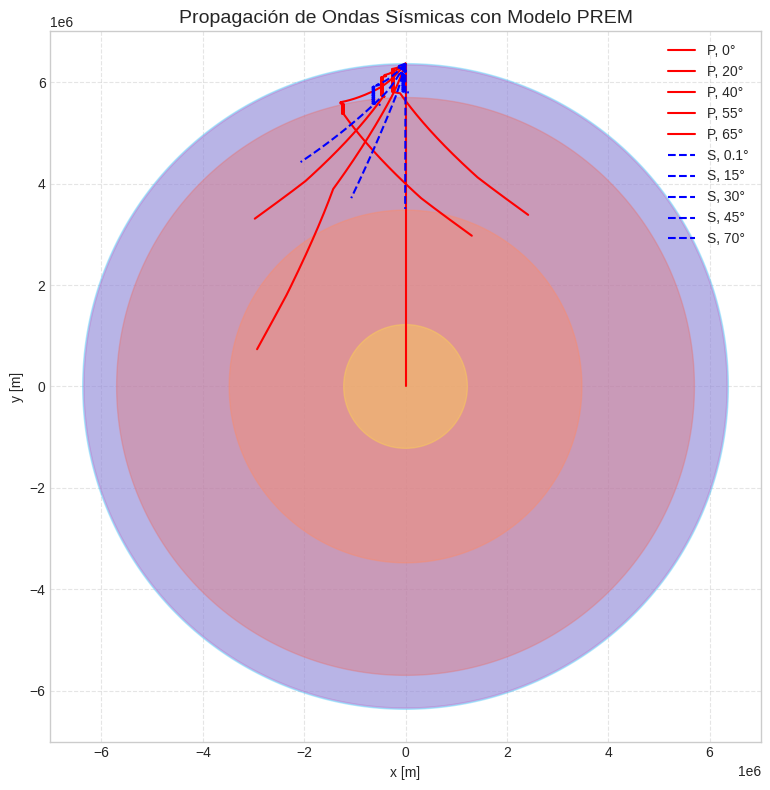

In [ ]:
# --- Interpolar datos PREM ---
r_prem = np.array(prem.radius[::-1]) * 1000  # m
vp_prem = np.array(prem.Vpv[::-1]) * 1000    # m/s
vs_prem = np.array(prem.Vsv[::-1]) * 1000    # m/s

# Crear funciones de velocidad vs. radio
vp_interp = interp1d(r_prem, vp_prem, bounds_error=False,
                     fill_value="extrapolate")
vs_interp = interp1d(r_prem, vs_prem, bounds_error=False,
                     fill_value="extrapolate")

# --- Definir capas ---
R = 6371e3
n_capas = 200
radios = np.linspace(0, R, n_capas + 1)
v_p = vp_interp(radios)
v_s = vs_interp(radios)

# --- Función para ray tracing 2D ---
def trazar_rayo(v, angulo_inicial_deg, tipo="P"):
    x, y = [0], [R]
    theta = np.radians(angulo_inicial_deg)

    for i in range(n_capas):
        r1 = radios[n_capas - i]
        r2 = radios[n_capas - i - 1]
        v1 = v[n_capas - i]
        v2 = v[n_capas - i - 1]

        # Bloqueo de ondas S en el núcleo líquido
        if tipo == "S" and r2 < 3480e3:
            break

        # Ley de Snell
        sin_theta2 = v2 / v1 * np.sin(theta)

        if abs(sin_theta2) >= np.sin(np.radians(80)):
            theta = -theta  # Reflexión
        else:
            theta = np.arcsin(sin_theta2)

        dr_local = r1 - r2
        dx = dr_local * np.sin(theta)
        dy = -dr_local * np.cos(theta)

        x.append(x[-1] + dx)
        y.append(y[-1] + dy)

    return x, y

# --- Graficar resultados ---
plt.figure(figsize=(8, 8))
plt.gca().set_aspect('equal')

# Colores diferenciados para cada capa
colores_capas = [
    ("#FFD54F", 1221e3),  # Núcleo interno - amarillo
    ("#FF8A65", 3480e3),  # Núcleo externo - naranja
    ("#E57373", 5701e3),  # Manto inferior - rojo claro
    ("#BA68C8", 6346e3),  # Manto superior - violeta
    ("#4FC3F7", 6371e3)   # Corteza - celeste
]

# Dibujar capas desde afuera hacia adentro
ang = np.linspace(0, 2*np.pi, 400)
for i in reversed(range(len(colores_capas))):
    color, radio = colores_capas[i]
    plt.fill(radio*np.cos(ang), radio*np.sin(ang), color=color, alpha=0.4)

# Rayos P en rojo
for ang in [0, 20, 40, 55, 65]:
    x, y = trazar_rayo(v_p, ang, tipo="P")
    plt.plot(x, y, color="red", lw=1.5, label=f"P, {ang}°")

# Rayos S en azul punteado
for ang in [0.1, 15, 30, 45, 70]:
    x, y = trazar_rayo(v_s, ang, tipo="S")
    plt.plot(x, y, color="blue", lw=1.5, linestyle="--", label=f"S, {ang}°")

# Decoración
plt.title("Propagación de Ondas Sísmicas con Modelo PREM", fontsize=14)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()